In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("train.csv")
df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [3]:
df_test = pd.read_csv("test.csv")
df_test.shape
df_test.dtypes

id                               int64
Age                              int64
Annual_Income_USD              float64
Daily_Commute_km               float64
Number_of_Cars_Owned             int64
Charging_Stations_Near_Home      int64
Charging_Stations_Near_Work      int64
Environmental_Concern_Level    float64
Gender                          object
City_Type                       object
Current_Car_Type                object
Home_Charging_Possible          object
Subsidy_Available               object
Range_Anxiety_Level             object
dtype: object

In [4]:
df.shape

(668665, 15)

In [5]:
df.info(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [6]:
df.describe()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,334332.000000,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,193027.103211,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,0.000000,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,167166.000000,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,334332.000000,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,501498.000000,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,668664.000000,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


In [7]:
df.isnull().sum()

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64

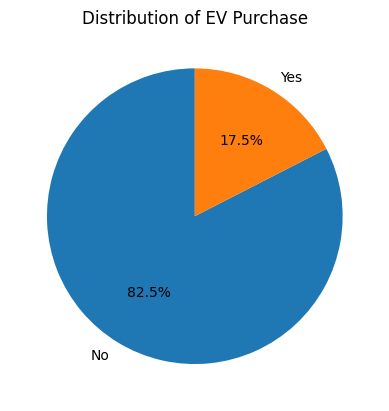

In [8]:
class_count = df["Will_Buy_EV"].value_counts()
plt.pie(class_count,
        labels=class_count.index,
        autopct="%1.1f%%",
        startangle=90)
plt.title("Distribution of EV Purchase")
plt.show()


Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13  Range_Anxiety_Level          668665 non-null  object 
 14  Will_Buy_EV        

In [9]:
df.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [10]:
def count_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    return len(outliers)

In [11]:
income_outliers = count_outliers(df, 'Annual_Income_USD')
commute_outliers = count_outliers(df, 'Daily_Commute_km')

print("Number of outliers in income:", income_outliers)
print("Number of outliers in commute distance:", commute_outliers)

Number of outliers in income: 3678
Number of outliers in commute distance: 41


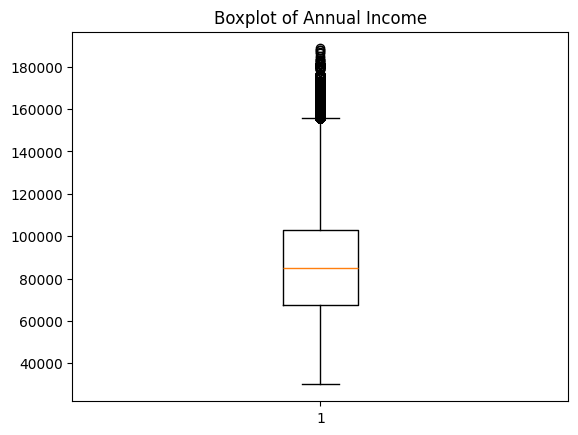

In [12]:
plt.boxplot(df['Annual_Income_USD'])
plt.title("Boxplot of Annual Income")
plt.show()

In [13]:
print(df['Annual_Income_USD'].min())
print(df['Annual_Income_USD'].max())

30000.0
188549.0


In [14]:
outlier_percentage = (income_outliers / len(df)) * 100

print(f"Outliers: {outlier_percentage:.2f}%")

Outliers: 0.55%


In [15]:
categorical_features = [
    'Gender',
    'City_Type',
    'Current_Car_Type',
    'Home_Charging_Possible',
    'Subsidy_Available',
    'Range_Anxiety_Level'
]

In [16]:
numeric_features = [
    'Age',
    'Annual_Income_USD',
    'Daily_Commute_km',
    'Number_of_Cars_Owned',
    'Charging_Stations_Near_Home',
    'Charging_Stations_Near_Work',
    'Environmental_Concern_Level'
]

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [18]:
X = df.drop(columns=['Will_Buy_EV', 'id'])
y = df['Will_Buy_EV']

X_test = df_test.drop(columns=['id'])

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'num',
            StandardScaler(),
            numeric_features
        )
    ]
)

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs'
)

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', model)
])

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

y_pred = pipeline.predict(X_val)
y_prob = pipeline.predict_proba(X_val)[:, 1]

print("Accuracy :", accuracy_score(y_val, y_pred))

print("Precision:", precision_score(
    y_val, y_pred, pos_label='Yes'
))

print("Recall   :", recall_score(
    y_val, y_pred, pos_label='Yes'
))

print("F1 Score :", f1_score(
    y_val, y_pred, pos_label='Yes'
))

# ROC-AUC
# Convert Yes/No into 1/0 only for ROC-AUC calculation
y_val_binary = (y_val == 'Yes').astype(int)

print("ROC-AUC  :", roc_auc_score(
    y_val_binary, y_prob
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_val,
    y_pred,
    labels=['No', 'Yes']
))

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_pred,
    labels=['No', 'Yes']
))

Accuracy : 0.8565649465726485
Precision: 0.5553933538592207
Recall   : 0.8959153964719986
F1 Score : 0.685705859221392
ROC-AUC  : 0.9379578338545865

Confusion Matrix:
[[93626 16751]
 [ 2431 20925]]

Classification Report:
              precision    recall  f1-score   support

          No       0.97      0.85      0.91    110377
         Yes       0.56      0.90      0.69     23356

    accuracy                           0.86    133733
   macro avg       0.77      0.87      0.80    133733
weighted avg       0.90      0.86      0.87    133733



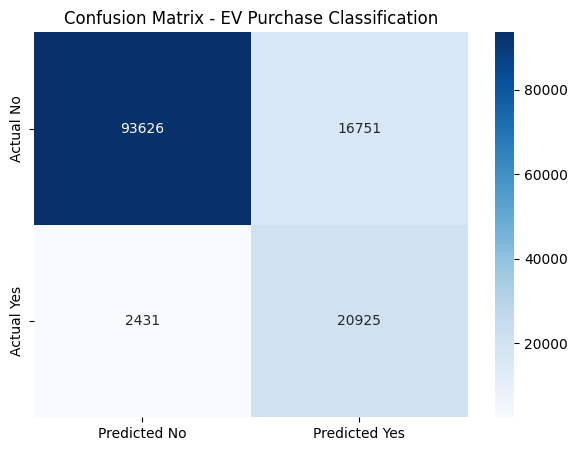

In [23]:
# Create confusion matrix
cm = confusion_matrix(
    y_val,
    y_pred,
    labels=['No', 'Yes']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes']
)

plt.title('Confusion Matrix - EV Purchase Classification')
plt.xlabel('')
plt.ylabel('')

plt.show()

In [24]:
y_pred = pipeline.predict(X_val)

In [25]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

y_prob = pipeline.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.05)

for threshold in thresholds:
    
    y_pred_threshold = np.where(
        y_prob >= threshold,
        'Yes',
        'No'
    )
    
    precision = precision_score(
        y_val,
        y_pred_threshold,
        pos_label='Yes'
    )
    
    recall = recall_score(
        y_val,
        y_pred_threshold,
        pos_label='Yes'
    )
    
    f1 = f1_score(
        y_val,
        y_pred_threshold,
        pos_label='Yes'
    )
    
    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.345 | Recall: 0.986 | F1: 0.511
Threshold: 0.15 | Precision: 0.386 | Recall: 0.979 | F1: 0.554
Threshold: 0.20 | Precision: 0.424 | Recall: 0.970 | F1: 0.590
Threshold: 0.25 | Precision: 0.448 | Recall: 0.964 | F1: 0.612
Threshold: 0.30 | Precision: 0.468 | Recall: 0.956 | F1: 0.628
Threshold: 0.35 | Precision: 0.488 | Recall: 0.946 | F1: 0.644
Threshold: 0.40 | Precision: 0.509 | Recall: 0.933 | F1: 0.658
Threshold: 0.45 | Precision: 0.533 | Recall: 0.914 | F1: 0.673
Threshold: 0.50 | Precision: 0.555 | Recall: 0.896 | F1: 0.686
Threshold: 0.55 | Precision: 0.572 | Recall: 0.879 | F1: 0.693
Threshold: 0.60 | Precision: 0.586 | Recall: 0.860 | F1: 0.697
Threshold: 0.65 | Precision: 0.604 | Recall: 0.835 | F1: 0.701
Threshold: 0.70 | Precision: 0.627 | Recall: 0.805 | F1: 0.705
Threshold: 0.75 | Precision: 0.657 | Recall: 0.755 | F1: 0.703
Threshold: 0.80 | Precision: 0.697 | Recall: 0.693 | F1: 0.695
Threshold: 0.85 | Precision: 0.730 | Recall: 0.628 | F1

In [26]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.60, 0.751, 0.01)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:

    y_pred_threshold = np.where(
        y_prob >= threshold,
        'Yes',
        'No'
    )

    f1 = f1_score(
        y_val,
        y_pred_threshold,
        pos_label='Yes'
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 0.7000000000000001
Best F1: 0.7047472741578927


In [27]:
import numpy as np

# Get probability of "Yes"
y_prob = pipeline.predict_proba(X_val)[:, 1]

# Apply 0.70 threshold
y_pred_70 = np.where(
    y_prob >= 0.70,
    'Yes',
    'No'
)

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_val, y_pred_70))

print("Precision:",
      precision_score(y_val, y_pred_70, pos_label='Yes'))

print("Recall   :",
      recall_score(y_val, y_pred_70, pos_label='Yes'))

print("F1 Score :",
      f1_score(y_val, y_pred_70, pos_label='Yes'))

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val,
        y_pred_70,
        labels=['No', 'Yes']
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_pred_70,
        labels=['No', 'Yes']
    )
)

Accuracy : 0.8821532456461756
Precision: 0.6265072280327759
Recall   : 0.8053176913855112
F1 Score : 0.7047472741578927

Confusion Matrix:
[[99164 11213]
 [ 4547 18809]]

Classification Report:
              precision    recall  f1-score   support

          No       0.96      0.90      0.93    110377
         Yes       0.63      0.81      0.70     23356

    accuracy                           0.88    133733
   macro avg       0.79      0.85      0.82    133733
weighted avg       0.90      0.88      0.89    133733



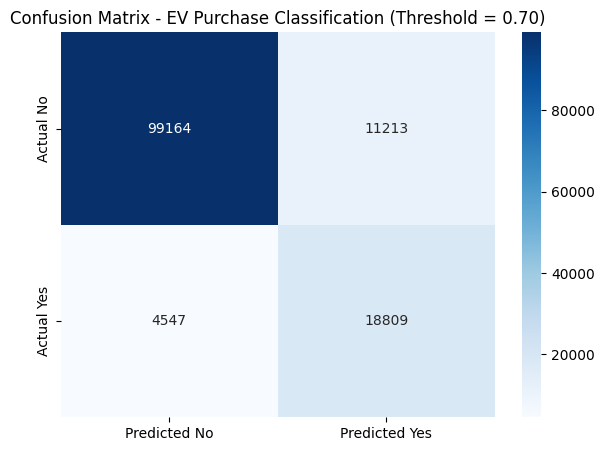

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_val,
    y_pred_70,
    labels=['No', 'Yes']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes']
)

plt.title('Confusion Matrix - EV Purchase Classification (Threshold = 0.70)')
plt.xlabel('')
plt.ylabel('')

plt.show()

In [30]:
# Separate features and target
X_final = df.drop(columns=['Will_Buy_EV', 'id'])
y_final = df['Will_Buy_EV']

print("Training features:", X_final.shape)
print("Training target:", y_final.shape)

Training features: (668665, 13)
Training target: (668665,)


In [31]:
# Train the final model on the complete training dataset
pipeline.fit(X_final, y_final)

print("Final model trained successfully.")

Final model trained successfully.


In [32]:
print("Test data shape:", X_test.shape)

Test data shape: (286571, 13)


In [33]:
test_prob = pipeline.predict_proba(X_test)[:, 1]

In [34]:
test_predictions = np.where(
    test_prob >= 0.70,
    'Yes',
    'No'
)

In [35]:
prediction_counts = pd.Series(test_predictions).value_counts()

print(prediction_counts)

print("\nPrediction percentages:")
print(
    pd.Series(test_predictions)
    .value_counts(normalize=True)
    .mul(100)
)

No     222778
Yes     63793
Name: count, dtype: int64

Prediction percentages:
No     77.739199
Yes    22.260801
Name: proportion, dtype: float64


In [36]:
import joblib

joblib.dump(
    pipeline,
    'ev_model.pkl'
)

print("Model saved successfully!")

Model saved successfully!
